# Machine Learning Systems for Sleep Quality Assessment Based on EEG Signals

---

* **Author**: Carmen-Theodora Craciun
* **Previos step**:
  * all ETL steps from folder `/datasets_ETL`
  * Feature extraction step
* **The purpose of this Notebook**:
* **Datasets**:
  * [Sleep-EDFX Database](https://www.physionet.org/content/sleep-edfx/1.0.0/) - channel EEG Fpz-Cz
  * [University College Dublin Sleep Apnea Database](https://physionet.org/content/ucddb/1.0.0/) - channel EEG C3-A2
  * [Haaglanden Medisch Centrum sleep staging database (PhysioNet)](https://physionet.org/content/hmc-sleep-staging/1.1/recordings/#files-panel) - channel EEG C4-M1
* **Input**:
    * `ML_train_features.csv`
    * `ML_test_features.csv`
    * `ML_test_features.csv`
* **Output:** *text cursiv*


# Imports

In [ ]:
!pip install catboost

In [ ]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, GroupKFold
from imblearn.over_sampling import SMOTE
from collections import Counter
import time
from scipy.signal import medfilt
from sklearn.utils.class_weight import compute_sample_weight
import joblib
import os
from scipy.stats import zscore

from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import xgboost as xgb
import lightgbm as lgb

In [ ]:
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/sleep_data/process_dataset'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Datasets

In [ ]:
df_train = pd.read_csv(base_path + '/ml_dataset/train_features.csv')
df_val = pd.read_csv(base_path + '/ml_dataset/val_features.csv')
df_test = pd.read_csv(base_path + '/ml_dataset/test_features.csv')

In [ ]:
X_train = df_train.drop('Label', axis=1)
y_train = df_train['Label']

X_val = df_val.drop('Label', axis=1)
y_val = df_val['Label']

X_test = df_test.drop('Label', axis=1)
y_test = df_test['Label']

In [ ]:
df_train.head()

,Subject_ID,Dataset_Source,Mean,Std,Skewness,Kurtosis,Zero_Crossings,Abs_Delta,Abs_Theta,Abs_Alpha,Abs_Sigma,Abs_Beta,Abs_Total,Rel_Delta,Rel_Theta,Rel_Alpha,Rel_Sigma,Rel_Beta,Label
0,1,0,-0.429715,50.406050,-26.741851,1125.532264,1153,685.856860,483.534935,379.917778,352.970003,1291.015457,3872.918762,0.177090,0.124850,0.098096,0.091138,0.333344,0
1,1,0,-0.860650,92.382850,0.635777,8.816965,802,8122.265734,61.634238,24.621977,22.581916,46.442297,9328.269587,0.870715,0.006607,0.002640,0.002421,0.004979,0
2,1,0,1.408013,39.325005,1.371603,9.175044,775,1513.530883,42.626117,23.411200,13.720810,15.159666,1781.254720,0.849699,0.023930,0.013143,0.007703,0.008511,0
3,1,0,0.367535,27.259431,1.709819,17.910265,908,917.452945,21.020428,15.676385,8.627362,14.673112,1085.139324,0.845470,0.019371,0.014446,0.007950,0.013522,0
4,1,0,-0.572789,15.452458,-0.169122,7.011664,813,174.494141,15.795249,19.390871,7.220864,10.013620,245.803829,0.709892,0.064260,0.078888,0.029377,0.040738,0


## SMOTE

In [ ]:
print("--- Class distribution before ---")
print(Counter(y_train))

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- Class distribution after ---")
print(Counter(y_train_smote))

--- Class distribution before ---
Counter({2: 87244, 0: 48348, 4: 35368, 3: 31587, 1: 25666})

--- Class distribution after ---
Counter({0: 87244, 1: 87244, 2: 87244, 3: 87244, 4: 87244})


## Normalize & Temporal Context

In [ ]:
def normalize_zscore_subject(df, feature_cols):
    '''
    Apply Z-Score normalization per patient (Subject_ID).
    Brings signals from different electrodes (Fpz, C3, C4) to the same common denominator.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.
    - feature_cols (list): List of column names

    Returns:
    - pd.DataFrame: The normalized DataFrame.
    '''
    df_norm = df.copy()
    # Aplicăm zscore pentru fiecare trăsătură, grupat după pacient
    for col in feature_cols:
        df_norm[col] = df_norm.groupby('Subject_ID')[col].transform(zscore)
    # Umplem eventualele NaN-uri (dacă deviația standard a fost 0)
    df_norm[feature_cols] = df_norm[feature_cols].fillna(0)
    return df_norm

In [ ]:
def add_subject_isolated_temporal_context(df):
    '''
    Adds temporal context (lag/lead) strictly isolated within each subject's data. This prevents 'data leakage' between different patients.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing multiple subjects.

    Returns:
    - pd.DataFrame: The DataFrame with patient-isolated temporal context.
    '''
    df_new = df.copy()

    # Exclude the ID, Source and Label from the shift
    cols_to_shift = [c for c in df_new.columns if c not in ['Subject_ID', 'Dataset_Source', 'Label']]

    def shift_group(group):
        for col in cols_to_shift:
            group[f'{col}_lag2'] = group[col].shift(2)
            group[f'{col}_lag1'] = group[col].shift(1)
            group[f'{col}_lead1'] = group[col].shift(-1)
            group[f'{col}_lead2'] = group[col].shift(-2)

        group.bfill(inplace=True)
        group.ffill(inplace=True)
        return group

    df_new = df_new.groupby('Subject_ID', group_keys=False).apply(shift_group, include_groups=False)
    return df_new

In [ ]:
# Only the temporal context
print("Before temporal context: ", df_train.shape)
df_train_isolated = add_subject_isolated_temporal_context(df_train)
df_val_isolated = add_subject_isolated_temporal_context(df_val)
print("After temporal context: ", df_train_isolated.shape)

X_train_isolated = df_train_isolated.drop('Label', axis=1)
y_train_isolated = df_train_isolated['Label']

X_val_isolated = df_val_isolated.drop('Label', axis=1)
y_val_isolated = df_val_isolated['Label']

Before temporal context:  (228213, 19)
After temporal context:  (228213, 82)


In [ ]:
col_normalize = [
    'Mean', 'Std', 'Skewness', 'Kurtosis', 'Zero_Crossings',
    'Abs_Delta', 'Abs_Theta', 'Abs_Alpha', 'Abs_Sigma', 'Abs_Beta', 'Abs_Total',
    'Rel_Delta', 'Rel_Theta', 'Rel_Alpha', 'Rel_Sigma', 'Rel_Beta'
]

print("Before normalization: ", df_train.shape)
df_train_norm = normalize_zscore_subject(df_train, col_normalize)
df_val_norm = normalize_zscore_subject(df_val, col_normalize)
print("After normalization: ", df_train_norm.shape)

df_train_norm_temp_ctxt = add_subject_isolated_temporal_context(df_train_norm)
df_val_norm_temp_ctxt = add_subject_isolated_temporal_context(df_val_norm)
print("After temporal context: ", df_train_norm_temp_ctxt.shape)

df_train_norm_temp_ctxt['Dataset_Source'] = df_train_norm_temp_ctxt['Dataset_Source'].astype('category')
df_val_norm_temp_ctxt['Dataset_Source'] = df_val_norm_temp_ctxt['Dataset_Source'].astype('category')

X_train_norm_temp_ctxt = df_train_norm_temp_ctxt.drop(['Label'], axis=1)
y_train_norm_temp_ctxt = df_train_norm_temp_ctxt['Label']

X_val_norm_temp_ctxt = df_val_norm_temp_ctxt.drop(['Label'], axis=1)
y_val_norm_temp_ctxt = df_val_norm_temp_ctxt['Label']

Before normalization:  (228213, 19)
After normalization:  (228213, 19)
After temporal context:  (228213, 82)


## Temporal and Statistical Features

In [ ]:
def create_enhanced_temporal_features(df):
    '''
    Extract Ratios, Lags, Leads, Diffs and Rolling Stats using ultra-fast vectorized operations, respecting per-patient isolation.

    Parameters:
    - df (pd.DataFrame): The input DataFrame.

    '''
    df_new = df.copy()

    # create ratio
    eps = 1e-6
    df_new['Ratio_DeepSleep'] = df_new['Abs_Delta'] / (df_new['Abs_Beta'] + eps)
    df_new['Ratio_Transition'] = df_new['Abs_Theta'] / (df_new['Abs_Alpha'] + eps)

    # Exclude columns
    exclude_cols = ['Subject_ID', 'Dataset_Source', 'Label']
    feature_cols = [c for c in df_new.columns if c not in exclude_cols]

    # Group by subject_id
    grouped = df_new.groupby('Subject_ID')[feature_cols]

    # Caculate lags and leads and differantial
    lag1_df = grouped.shift(1).add_suffix('_lag1')
    lag2_df = grouped.shift(2).add_suffix('_lag2')
    lead1_df = grouped.shift(-1).add_suffix('_lead1')
    lead2_df = grouped.shift(-2).add_suffix('_lead2')
    diff_df = df_new[feature_cols].sub(grouped.shift(1)).add_suffix('_diff')

    roll_mean_df = grouped.transform(lambda x: x.rolling(window=5, min_periods=1, center=True).mean()).add_suffix('_roll_mean')
    roll_std_df = grouped.transform(lambda x: x.rolling(window=5, min_periods=1, center=True).std()).add_suffix('_roll_std')

    # Add the values
    df_final = pd.concat([df_new, lag1_df, lag2_df, lead1_df, lead2_df, diff_df, roll_mean_df, roll_std_df], axis=1)
    df_final = df_final.groupby('Subject_ID', group_keys=False).apply(lambda g: g.bfill().ffill(), include_groups=False)

    return df_final

df_train_rf = create_enhanced_temporal_features(df_train_norm)
df_val_rf = create_enhanced_temporal_features(df_val_norm)

X_train_rf = df_train_rf.drop(['Subject_ID', 'Dataset_Source', 'Label'], axis=1, errors='ignore')
y_train_rf = df_train_rf['Label']

X_val_rf = df_val_rf.drop(['Subject_ID', 'Dataset_Source', 'Label'], axis=1, errors='ignore')
y_val_rf = df_val_rf['Label']

print(f"New shape : {df_train_rf.shape}")

New shape : (228213, 146)


# Evaluation

In [ ]:
class_names = ['Wake', 'N1', 'N2', 'N3', 'REM']

def evaluare_model(y_true, y_pred, class_names=None):
    '''
    Evaluate the performance of a classification model.

    Parameters:
      - y_true (array-like): True labels.
      - y_pred (array-like): Predicted labels.
      - class_names (list): List of class names.
    '''
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy {acc:.4f}\n")

    print("--- Classification report ---")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True')
    plt.xlabel('Predicted')
    plt.show()

# XGBoost, LightGBM & CatBoost

## Baseline LightGBM with SMOTE

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.164499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4330
[LightGBM] [Info] Number of data points in the train set: 436220, number of used features: 18
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Train time: 59.06 seconds

Accuracy 0.5878

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.76      0.71      0.73     10361
          N1       0.29      0.33      0.31      6930
          N2       0.83      0.52      0.64     20785
          N3       0.58      0.85      0.69      6474
         REM       0.40      0.63      0.49      7574

    accuracy                           0

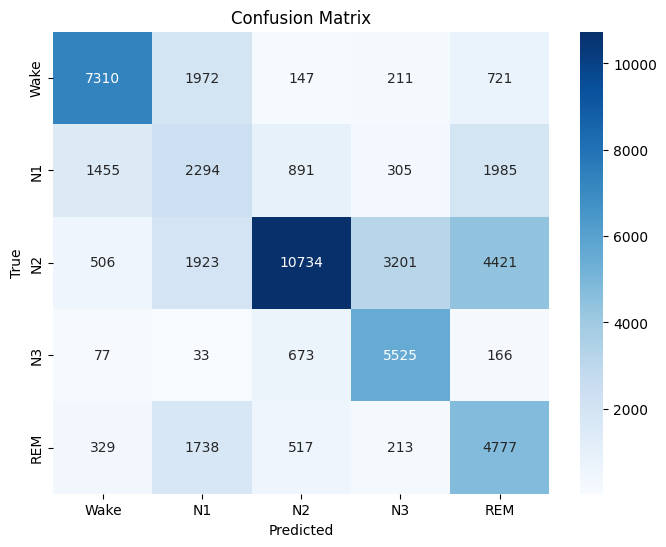

In [ ]:
lgb_baseline_smote = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    random_state=42,
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1
)

start_time_fit = time.time()
lgb_baseline_smote.fit(X_train_smote, y_train_smote)
print(f"Train time: {(time.time() - start_time_fit):.2f} seconds")

print()
y_pred_val_lgb = lgb_baseline_smote.predict(X_val)
evaluare_model(y_val, y_pred_val_lgb, class_names=class_names)

## LightGBM + Lag/Lead + Class Weights

/tmp/ipykernel_250/1537191386.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_new = df_new.groupby('Subject_ID', group_keys=False).apply(shift_group)
/tmp/ipykernel_250/1537191386.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_new = df_new.groupby('Subject_ID', group_keys=False).apply(shift_group)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.369226 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20403
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 81
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

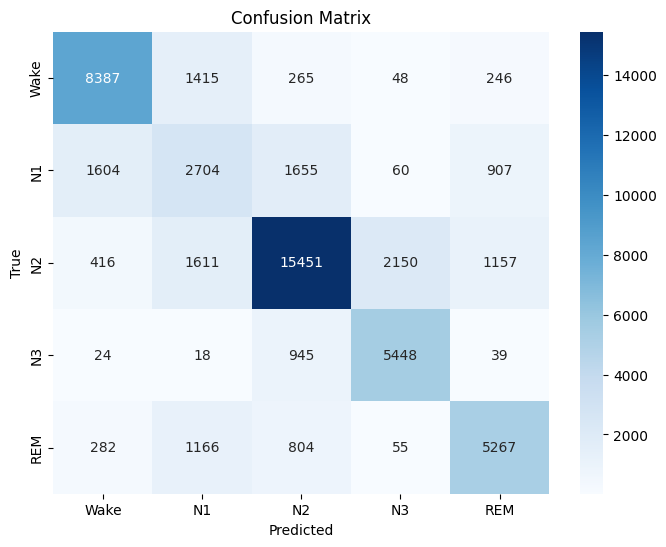

In [ ]:
lgb_lag = lgb.LGBMClassifier(
    n_estimators=500, # trees
    learning_rate=0.05,
    max_depth=10,
    num_leaves=150,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

start_time_fit = time.time()
lgb_lag.fit(X_train_isolated, y_train_isolated)
print(f"Train time: {(time.time() - start_time_fit):.2f} seconds")

y_pred_raw = lgb_lag.predict(X_val_isolated)

df_eval_lag = pd.DataFrame({
    'Subject_ID': df_val_isolated['Subject_ID'],
    'Label': y_val_isolated,
    'Pred_Raw': y_pred_raw
})

df_eval_lag['Pred_Smooth'] = df_eval_lag.groupby('Subject_ID')['Pred_Raw'].transform(lambda x: medfilt(x, kernel_size=3).astype(int))
evaluare_model(df_eval_lag['Label'], df_eval_lag['Pred_Smooth'], class_names=class_names)

## LightGBM + Z-Score + Dataset_Source

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.208395 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 20404
[LightGBM] [Info] Number of data points in the train set: 228213, number of used features: 81
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
Train time: 355.21 seconds
Accuracy 0.7281

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.82      0.80      0.81     10361
          N1       0.44      0.40      0.42      6930
          N2       0.78      0.78      0.78     20785
          N3       0.70      0.79      0.74      6474
         REM       0.72      0.72      0.72      7574

    accuracy                           

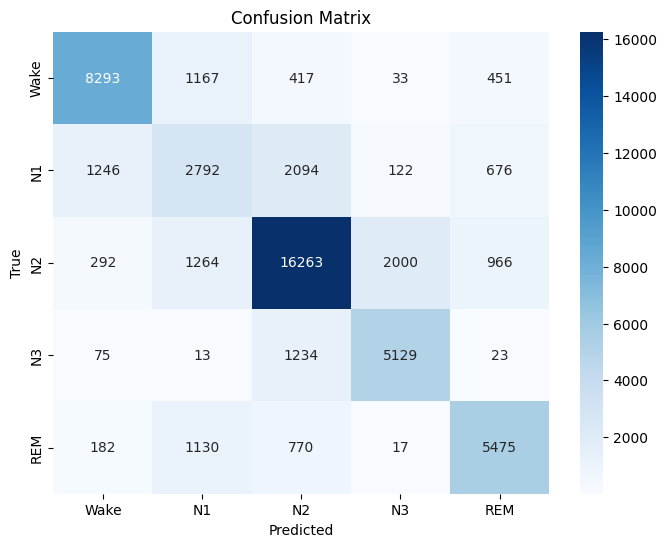

In [ ]:
lgb_zscore = lgb.LGBMClassifier(
    n_estimators=400,
    learning_rate=0.08,
    max_depth=10,
    num_leaves=125,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

start_time_fit = time.time()
lgb_zscore.fit(X_train_norm_temp_ctxt, y_train_norm_temp_ctxt)
print(f"Train time: {(time.time() - start_time_fit):.2f} seconds")

y_pred_raw = lgb_zscore.predict(X_val_norm_temp_ctxt)

df_eval = pd.DataFrame({
    'Subject_ID': df_val['Subject_ID'],
    'Label': y_val_norm_temp_ctxt,
    'Pred_Raw': y_pred_raw
})

df_eval['Pred_Smooth'] = df_eval.groupby('Subject_ID')['Pred_Raw'].transform(lambda x: medfilt(x, kernel_size=3).astype(int))

evaluare_model(df_eval['Label'], df_eval['Pred_Smooth'], class_names=class_names)

## XGBoost

Train time: 442.21 seconds
Accuracy 0.7270

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.83      0.80      0.81     10361
          N1       0.44      0.41      0.43      6930
          N2       0.79      0.76      0.78     20785
          N3       0.69      0.82      0.75      6474
         REM       0.71      0.74      0.72      7574

    accuracy                           0.73     52124
   macro avg       0.69      0.71      0.70     52124
weighted avg       0.73      0.73      0.73     52124



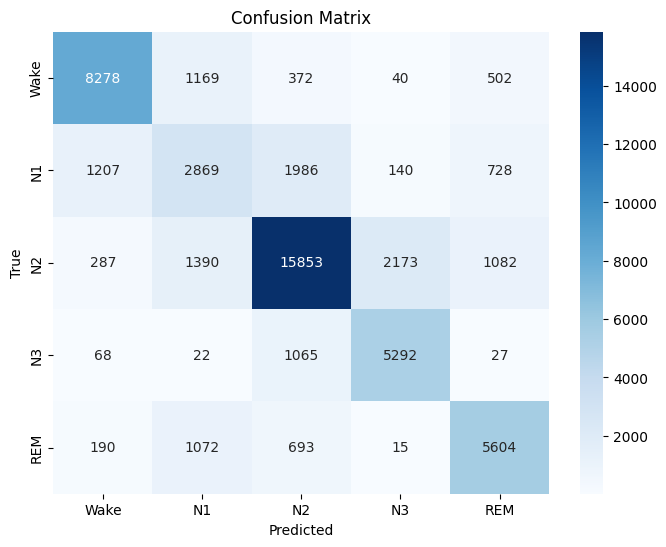

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_norm_temp_ctxt)

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42,
    n_estimators=400,
    learning_rate=0.08,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',          # Required to process categorical columns quickly
    enable_categorical=True,     # Read the Dataset Source column as a category
    n_jobs=-1
)

start_time = time.time()
xgb_model.fit(X_train_norm_temp_ctxt, y_train_norm_temp_ctxt, sample_weight=sample_weights)
print(f"Train time: {(time.time() - start_time):.2f} seconds")

y_pred_raw_xgb = xgb_model.predict(X_val_norm_temp_ctxt)

# Rebuild the evaluation table
df_eval_xgb = pd.DataFrame({
    'Subject_ID': df_val_norm_temp_ctxt['Subject_ID'],
    'Label': y_val_norm_temp_ctxt,
    'Pred_Raw': y_pred_raw_xgb
})

df_eval_xgb['Pred_Smooth'] = df_eval_xgb.groupby('Subject_ID')['Pred_Raw'].transform(lambda x: medfilt(x, kernel_size=3).astype(int))
evaluare_model(df_eval_xgb['Label'], df_eval_xgb['Pred_Smooth'], class_names=class_names)

## LightGBM + XGBoost with Soft Voting

Accuracy 0.7298

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.82      0.80      0.81     10361
          N1       0.45      0.41      0.43      6930
          N2       0.79      0.78      0.78     20785
          N3       0.70      0.80      0.75      6474
         REM       0.71      0.73      0.72      7574

    accuracy                           0.73     52124
   macro avg       0.69      0.70      0.70     52124
weighted avg       0.73      0.73      0.73     52124



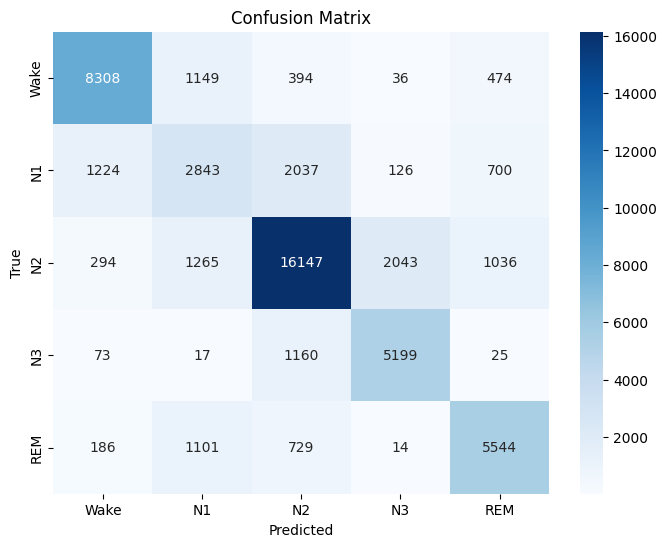

In [ ]:
probs_lgb = lgb_zscore.predict_proba(X_val_norm_temp_ctxt)
probs_xgb = xgb_model.predict_proba(X_val_norm_temp_ctxt)

probs_ensemble = (probs_lgb + probs_xgb) / 2.0

y_pred_raw_ens = np.argmax(probs_ensemble, axis=1)

df_eval_ens = pd.DataFrame({
    'Subject_ID': df_val_norm_temp_ctxt['Subject_ID'],
    'Label': y_val_norm_temp_ctxt,
    'Pred_Raw': y_pred_raw_ens
})

df_eval_ens['Pred_Smooth'] = df_eval_ens.groupby('Subject_ID')['Pred_Raw'].transform(lambda x: medfilt(x, kernel_size=3).astype(int))

evaluare_model(df_eval_ens['Label'], df_eval_ens['Pred_Smooth'], class_names=class_names)

## CatBoost

0:	learn: 1.5124174	test: 1.5196895	best: 1.5196895 (0)	total: 9.36s	remaining: 1h 17m 49s
100:	learn: 0.7023462	test: 0.8156023	best: 0.8156023 (100)	total: 6m 39s	remaining: 26m 18s
200:	learn: 0.6245846	test: 0.7887546	best: 0.7887546 (200)	total: 12m 29s	remaining: 18m 35s
300:	learn: 0.5749793	test: 0.7755721	best: 0.7755721 (300)	total: 18m 15s	remaining: 12m 3s
400:	learn: 0.5418268	test: 0.7680858	best: 0.7680858 (400)	total: 24m 1s	remaining: 5m 55s
499:	learn: 0.5152420	test: 0.7638553	best: 0.7638501 (498)	total: 29m 38s	remaining: 0us

bestTest = 0.7638501305
bestIteration = 498

Shrink model to first 499 iterations.
Train time: 1784.31 secunde
Accuracy 0.7063

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.83      0.77      0.80     10361
          N1       0.41      0.45      0.43      6930
          N2       0.83      0.69      0.75     20785
          N3       0.62      0.87      0.72      6474
         REM     

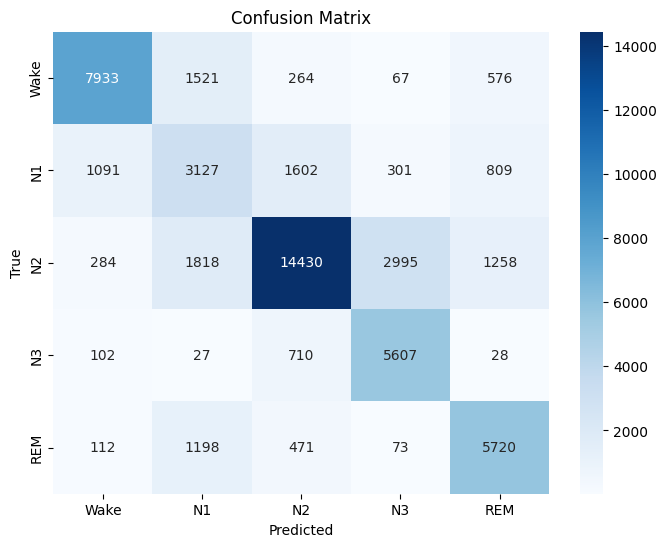

In [ ]:
X_train_cat = X_train_norm_temp_ctxt.copy()
X_val_cat = X_val_norm_temp_ctxt.copy()

X_train_cat['Dataset_Source'] = X_train_cat['Dataset_Source'].astype(int)
X_val_cat['Dataset_Source'] = X_val_cat['Dataset_Source'].astype(int)
categorical_features_indices = ['Dataset_Source']

cat_model = CatBoostClassifier(
    iterations=500,              # Trees
    learning_rate=0.08,
    depth=8,                     # Maximum depth of synthetic trees
    auto_class_weights='Balanced',
    cat_features=categorical_features_indices,
    random_seed=42,
    verbose=100                  # Shows progress every 100 steps
)

start_time = time.time()
cat_model.fit(X_train_cat, y_train_norm_temp_ctxt, eval_set=(X_val_cat, y_val_norm_temp_ctxt), early_stopping_rounds=50)
print(f"Train time: {(time.time() - start_time):.2f} secunde")

y_pred_raw_cat = cat_model.predict(X_val_cat).flatten() # Flatten because it returns a 2D array

df_eval_cat = pd.DataFrame({
    'Subject_ID': df_val_norm_temp_ctxt['Subject_ID'],
    'Label': y_val_norm_temp_ctxt,
    'Pred_Raw': y_pred_raw_cat
})

df_eval_cat['Pred_Smooth'] = df_eval_cat.groupby('Subject_ID')['Pred_Raw'].transform(lambda x: medfilt(x, kernel_size=3).astype(int))
evaluare_model(df_eval_cat['Label'], df_eval_cat['Pred_Smooth'], class_names=class_names)

## LightGBM + XGBoost + CatBoost Soft Voting

Accuracy 0.7273

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.84      0.79      0.81     10361
          N1       0.44      0.41      0.42      6930
          N2       0.79      0.77      0.78     20785
          N3       0.68      0.83      0.75      6474
         REM       0.72      0.74      0.73      7574

    accuracy                           0.73     52124
   macro avg       0.69      0.71      0.70     52124
weighted avg       0.73      0.73      0.73     52124



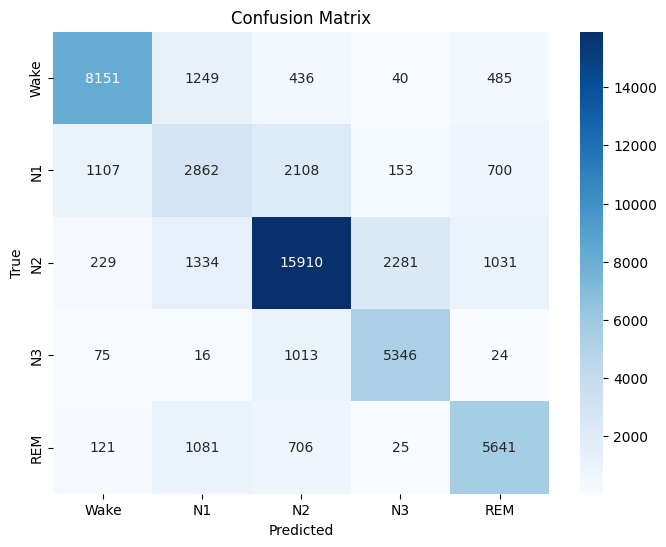

In [ ]:
probs_cat = cat_model.predict_proba(X_val_cat)

probs_ensemble_3way = (probs_lgb + probs_xgb + probs_cat) / 3.0

y_pred_raw_3way = np.argmax(probs_ensemble_3way, axis=1)

df_eval_3way = pd.DataFrame({
    'Subject_ID': df_val_norm_temp_ctxt['Subject_ID'],
    'Label': y_val_norm_temp_ctxt,
    'Pred_Raw': y_pred_raw_3way
})

df_eval_3way['Pred_Smooth'] = df_eval_3way.groupby('Subject_ID')['Pred_Raw'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))

evaluare_model(df_eval_3way['Label'], df_eval_3way['Pred_Smooth'], class_names=class_names)

# Random Forest

## RF with Temporal Context

Train time: 634.65 seconds
Accuracy 0.7056

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.73      0.80      0.76     10361
          N1       0.47      0.21      0.29      6930
          N2       0.73      0.83      0.78     20785
          N3       0.75      0.71      0.73      6474
         REM       0.66      0.70      0.68      7574

    accuracy                           0.71     52124
   macro avg       0.67      0.65      0.65     52124
weighted avg       0.69      0.71      0.69     52124



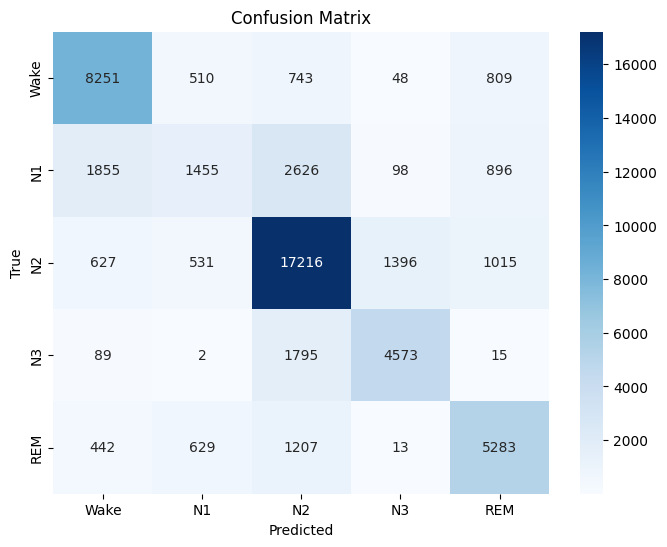

In [ ]:
start_time = time.time()

rf_adv = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_adv.fit(X_train_rf, y_train_rf)
print(f"Train time: {round(time.time() - start_time, 2)} seconds")

y_pred_rf = rf_adv.predict(X_val_rf)

evaluare_model(y_val_rf, y_pred_rf, class_names=class_names)

## RF Divide et Impera

Train time: 1246.48 seconds
Accuracy 0.6956

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.84      0.67      0.74     10361
          N1       0.44      0.26      0.33      6930
          N2       0.68      0.87      0.76     20785
          N3       0.77      0.65      0.71      6474
         REM       0.67      0.68      0.68      7574

    accuracy                           0.70     52124
   macro avg       0.68      0.63      0.64     52124
weighted avg       0.69      0.70      0.68     52124



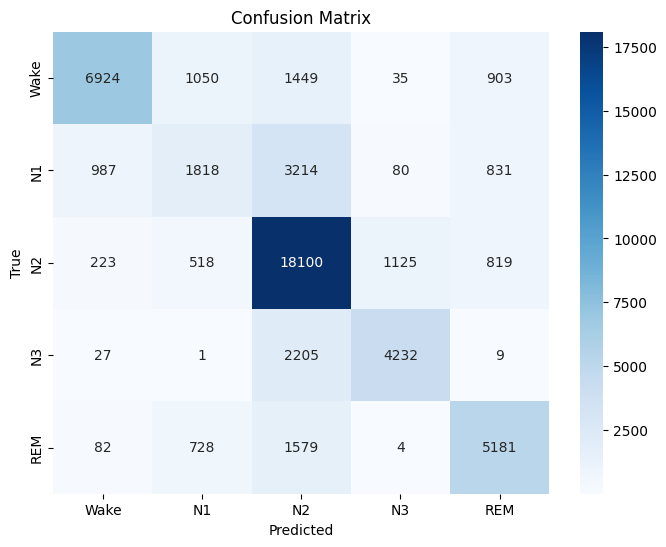

In [ ]:
start_time = time.time()

# Sleep vs wake
y_train_bin = y_train_rf.apply(lambda x: 0 if x == 0 else 1)
rf_binary = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_binary.fit(X_train_rf, y_train_bin)

# Only sleep stages
mask_sleep = y_train_rf != 0
X_train_sleep = X_train_rf[mask_sleep]
y_train_sleep = y_train_rf[mask_sleep]

rf_sleep = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_sleep.fit(X_train_sleep, y_train_sleep)

# Combine
preds_bin = rf_binary.predict(X_val_rf)
preds_sleep = rf_sleep.predict(X_val_rf)
y_pred_ierarhic = np.where(preds_bin == 0, 0, preds_sleep)

print(f"Train time: {round((time.time() - start_time), 2)} seconds")
evaluare_model(y_val_rf, y_pred_ierarhic, class_names=class_names)

## RF Clinical Approach

Train time: 961.71 seconds
Accuracy 0.7714

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.78      0.77      0.77     10361
          N2       0.79      0.83      0.81     27715
          N3       0.75      0.70      0.72      6474
         REM       0.71      0.62      0.66      7574

    accuracy                           0.77     52124
   macro avg       0.76      0.73      0.74     52124
weighted avg       0.77      0.77      0.77     52124



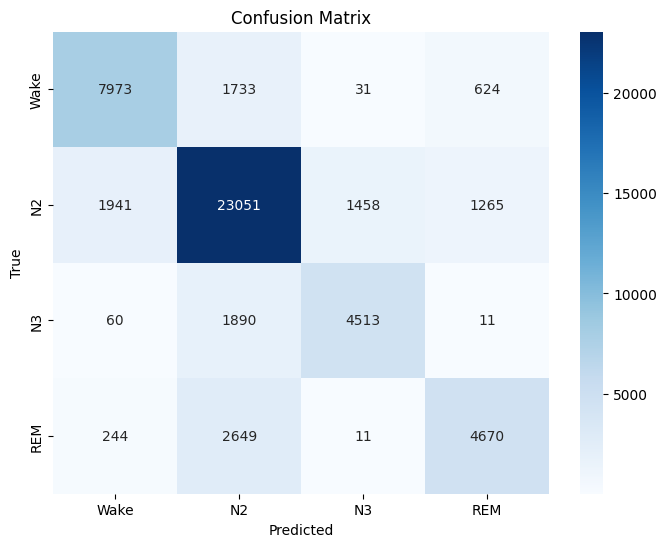

In [ ]:
# Combining N1 and N2
y_train_4c = y_train_rf.replace({1: 2})
y_val_4c = y_val_rf.replace({1: 2})


rf_4c = RandomForestClassifier(
    n_estimators=150,
    class_weight='balanced',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
rf_4c.fit(X_train_rf, y_train_4c)
print(f"Train time: {round((time.time() - start_time), 2)} seconds")

y_pred_4c = rf_4c.predict(X_val_rf)

clase_4 = ['Wake', 'N2', 'N3', 'REM']

evaluare_model(y_val_4c, y_pred_4c, class_names=clase_4)

To understand the limitations of Random Forest on this dataset, we conducted a secondary experiment in which we merged the N1 transition stage with the N2 stage.

In this 4-class configuration, the accuracy of the Random Forest model artificially increased to 77.14%. This experiment clearly demonstrates that the proposed algorithms are extremely capable of understanding the macro-structure of sleep, but the capping at ~73% in the real clinical scenario (5 classes) is strictly caused by the impossibility of separating the EEG waves from the N1 stage from those from Wake and N2 in the absence of eye movement (EOG) sensors.

# Cross-validation - Gradient Boosting Ensemble

In [ ]:
df_full = pd.concat([df_train_norm_temp_ctxt, df_val_norm_temp_ctxt], axis=0).reset_index(drop=True)

y_full = df_full['Label']
groups_full = df_full['Subject_ID']

# Prepare the Xs specific to each model
X_full_tree = df_full.drop(['Label', 'Subject_ID'], axis=1).copy()
X_full_tree['Dataset_Source'] = X_full_tree['Dataset_Source'].astype('category')

X_full_cat = df_full.drop(['Label', 'Subject_ID'], axis=1).copy()
X_full_cat['Dataset_Source'] = X_full_cat['Dataset_Source'].astype(int)

Data preparation


In [ ]:
n_splits = 5
gkf = GroupKFold(n_splits=n_splits)

cv_scores_3way = []

best_accuracy = 0.0
best_models = {}

In [ ]:
print(f"Start {n_splits}-Fold Cross Validation")
total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(gkf.split(X_full_tree, y_full, groups=groups_full)):
    print(f"\n=== FOLD {fold + 1} / {n_splits} ===")
    fold_start = time.time()

    # Split the data
    X_tr_tree, y_tr = X_full_tree.iloc[train_idx], y_full.iloc[train_idx]
    X_va_tree, y_va = X_full_tree.iloc[val_idx], y_full.iloc[val_idx]

    X_tr_cat, X_va_cat = X_full_cat.iloc[train_idx], X_full_cat.iloc[val_idx]
    val_subjects = groups_full.iloc[val_idx]

    # Train
    print("  -> Train LightGBM...")
    lgb_cv = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.08, max_depth=10, num_leaves=125, class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
    lgb_cv.fit(X_tr_tree, y_tr)
    probs_lgb = lgb_cv.predict_proba(X_va_tree)

    print("  -> Train XGBoost...")
    weights_xgb = compute_sample_weight(class_weight='balanced', y=y_tr)
    xgb_cv = xgb.XGBClassifier(objective='multi:softmax', num_class=5, eval_metric='mlogloss', random_state=42, n_estimators=400, learning_rate=0.08, max_depth=8, subsample=0.8, colsample_bytree=0.8, tree_method='hist', enable_categorical=True, n_jobs=-1)
    xgb_cv.fit(X_tr_tree, y_tr, sample_weight=weights_xgb)
    probs_xgb = xgb_cv.predict_proba(X_va_tree)

    print("  -> Train CatBoost...")
    cat_cv = CatBoostClassifier(iterations=300, learning_rate=0.08, depth=8, auto_class_weights='Balanced', cat_features=['Dataset_Source'], random_seed=42, verbose=0)
    cat_cv.fit(X_tr_cat, y_tr)
    probs_cat = cat_cv.predict_proba(X_va_cat)

    # Evaluete
    df_eval_fold = pd.DataFrame({'Subject_ID': val_subjects.values, 'Label': y_va.values})

    probs_ensemble_3way = (probs_lgb + probs_xgb + probs_cat) / 3.0
    df_eval_fold['Pred_Raw_3way'] = np.argmax(probs_ensemble_3way, axis=1)
    df_eval_fold['Pred_Smooth_3way'] = df_eval_fold.groupby('Subject_ID')['Pred_Raw_3way'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))

    acc_3way = accuracy_score(df_eval_fold['Label'], df_eval_fold['Pred_Smooth_3way'])
    cv_scores_3way.append(acc_3way)

    print(f"  [Scor Fold {fold+1}] 3-Way: {acc_3way:.4f} | Timp: {(time.time() - fold_start)/60:.1f} min")

    # Save best fold
    if acc_3way > best_accuracy:
        best_accuracy = acc_3way
        # Keep the reference to these trained models
        best_models['lgb'] = lgb_cv
        best_models['xgb'] = xgb_cv
        best_models['cat'] = cat_cv
        print(f"  ! New best ({best_accuracy:.4f})!")

Start 5-Fold Cross Validation

=== FOLD 1 / 5 ===
  -> Train LightGBM...
  -> Train XGBoost...
  -> Train CatBoost...
  [Scor Fold 1] 3-Way: 0.7317 | Timp: 27.7 min

=== FOLD 2 / 5 ===
  -> Train LightGBM...
  -> Train XGBoost...
  -> Train CatBoost...
  [Scor Fold 2] 3-Way: 0.7452 | Timp: 27.9 min

=== FOLD 3 / 5 ===
  -> Train LightGBM...
  -> Train XGBoost...
  -> Train CatBoost...
  [Scor Fold 3] 3-Way: 0.7467 | Timp: 27.5 min

=== FOLD 4 / 5 ===
  -> Train LightGBM...
  -> Train XGBoost...
  -> Train CatBoost...
  [Scor Fold 4] 3-Way: 0.7492 | Timp: 27.9 min

=== FOLD 5 / 5 ===
  -> Train LightGBM...
  -> Train XGBoost...
  -> Train CatBoost...
  [Scor Fold 5] 3-Way: 0.7349 | Timp: 27.8 min


In [ ]:
print(f"=== FINAL CROSS-VALIDATION RESULTS ===")
print(f"Average Accuracy = {np.mean(cv_scores_3way):.4f} ± {np.std(cv_scores_3way):.4f}")
print("="*50)

print(f"\nSaving the models from the winning fold (Accuracy: {best_accuracy:.4f})...")

models_path = base_path + "/../models/"

joblib.dump(best_models['lgb'], models_path + 'best_lgb.pkl')
best_models['xgb'].save_model(models_path + 'best_xgb.json')
best_models['cat'].save_model(models_path + 'best_cat.cbm')

print("The best models have been successfully saved in the 'best_ensemble_models' folder!")

=== FINAL CROSS-VALIDATION RESULTS ===
Average Accuracy = 0.7423 ± 0.0069

Saving the models from the winning fold (Accuracy: 0.7492)...
The best models have been successfully saved in the 'best_ensemble_models' folder!


# Test Dataset

In [ ]:
df_test_norm = normalize_zscore_subject(df_test, col_normalize)
df_test_norm_temp_ctxt = add_subject_isolated_temporal_context(df_test_norm)
df_test_norm_temp_ctxt['Dataset_Source'] = df_test_norm_temp_ctxt['Dataset_Source'].astype('category')

X_test_norm_temp_ctxt = df_test_norm_temp_ctxt.drop(['Label'], axis=1)
y_test_norm_temp_ctxt = df_test_norm_temp_ctxt['Label']

test_subjects = df_test['Subject_ID']
y_test_final = df_test_norm_temp_ctxt['Label']

# A. Setul pentru LightGBM și XGBoost (Eliminăm Label)
X_test_tree = df_test_norm_temp_ctxt.drop(['Label'], axis=1).copy()
# Dataset_Source este deja 'category' din codul tău anterior, deci e perfect!

# B. Setul pentru CatBoost (Dataset_Source trebuie să fie int)
X_test_cat = df_test_norm_temp_ctxt.drop(['Label'], axis=1).copy()
X_test_cat['Dataset_Source'] = X_test_cat['Dataset_Source'].astype(int)

In [ ]:
models_path = base_path + "/../models/"  # Sau cum l-ai definit tu exact

lgb_loaded = joblib.load(models_path + 'best_lgb.pkl')

xgb_loaded = xgb.XGBClassifier()
xgb_loaded.load_model(models_path + 'best_xgb.json')

cat_loaded = CatBoostClassifier()
cat_loaded.load_model(models_path + 'best_cat.cbm')

df_eval_test = pd.DataFrame({
    'Subject_ID': test_subjects.values,
    'Label': y_test_final.values
})

Accuracy LightGBM: 0.7530


Accuracy XGBoost:  0.7512


Accuracy CatBoost: 0.7227

------------------------
Accuracy 0.7503

--- Classification report ---
              precision    recall  f1-score   support

        Wake       0.80      0.80      0.80      7687
          N1       0.41      0.43      0.42      5307
          N2       0.82      0.78      0.80     20469
          N3       0.73      0.82      0.77      6930
         REM       0.78      0.79      0.78      7937

    accuracy                           0.75     48330
   macro avg       0.71      0.72      0.72     48330
weighted avg       0.75      0.75      0.75     48330



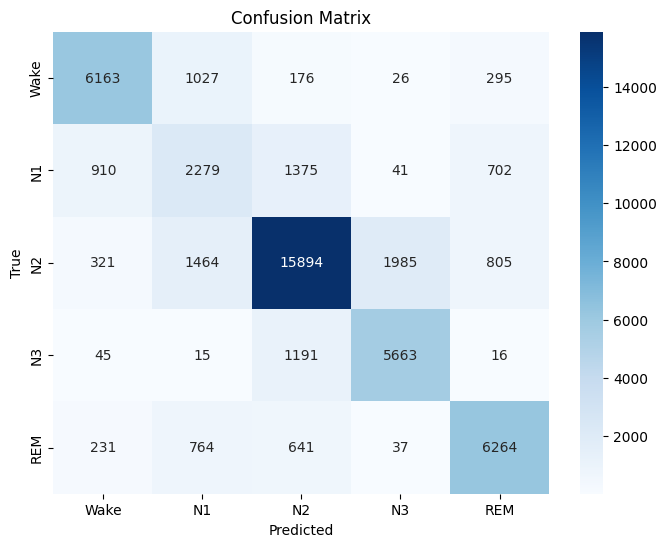

In [ ]:
probs_lgb = lgb_loaded.predict_proba(X_test_tree)

y_pred_raw_lgb = np.argmax(probs_lgb, axis=1)
df_eval_test['Pred_LGB'] = y_pred_raw_lgb
df_eval_test['Smooth_LGB'] = df_eval_test.groupby('Subject_ID')['Pred_LGB'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))
acc_lgb = accuracy_score(df_eval_test['Label'], df_eval_test['Smooth_LGB'])
print(f"Accuracy LightGBM: {acc_lgb:.4f}\n")

probs_xgb = xgb_loaded.predict_proba(X_test_tree)

y_pred_raw_xgb = np.argmax(probs_xgb, axis=1)
df_eval_test['Pred_XGB'] = y_pred_raw_xgb
df_eval_test['Smooth_XGB'] = df_eval_test.groupby('Subject_ID')['Pred_XGB'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))
acc_xgb = accuracy_score(df_eval_test['Label'], df_eval_test['Smooth_XGB'])
print(f"\nAccuracy XGBoost:  {acc_xgb:.4f}\n")

probs_cat = cat_loaded.predict_proba(X_test_cat)

y_pred_raw_cat = np.argmax(probs_cat, axis=1)
df_eval_test['Pred_CAT'] = y_pred_raw_cat
df_eval_test['Smooth_CAT'] = df_eval_test.groupby('Subject_ID')['Pred_CAT'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))
acc_cat = accuracy_score(df_eval_test['Label'], df_eval_test['Smooth_CAT'])
print(f"\nAccuracy CatBoost: {acc_cat:.4f}")

print("\n------------------------")
probs_ensemble = (probs_lgb + probs_xgb + probs_cat) / 3.0

y_pred_raw_3way = np.argmax(probs_ensemble, axis=1)

df_eval_test['Pred_Raw'] = y_pred_raw_3way
df_eval_test['Pred_Smooth'] = df_eval_test.groupby('Subject_ID')['Pred_Raw'].transform(lambda x: medfilt(x, kernel_size=5).astype(int))

acc_ens = accuracy_score(df_eval_test['Label'], df_eval_test['Pred_Smooth'])

evaluare_model(df_eval_test['Label'], df_eval_test['Pred_Smooth'], class_names=class_names)